In [1]:
import torch
import math
torch.manual_seed(42)

# Create Dataset - Multi Class Data

In [ ]:
n_sample = 100

A = torch.randn(n_sample, 2) + torch.tensor([-3., -3.])
B = torch.randn(n_sample, 2) + torch.tensor([ 3., -3.])
C = torch.randn(n_sample, 2) + torch.tensor([ 0.,  3.])

X = torch.cat((A, B, C), dim=0)

y = torch.cat((
    torch.zeros(n_sample),
    torch.ones(n_sample),
    torch.full((n_sample,), 2)
)).long()  # Converting to long (int64) so it can be used for indexing in CrossEntropy Loss

In [29]:
X.shape, y.shape

(torch.Size([300, 2]), torch.Size([300]))

# Softmax Class
## The Softmax function converts logits (raw scores) into probabilities.

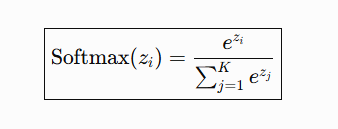

### Suppose model outputs logits: 0,1,2. Exponentiate each value; e^0, e^1, e^2 and divide each of them by their sum.
### So, Softmax(0) = e^0 / (e^0+e^1+e^2)
### And the input to softmax is raw logits and output is the probabilities of those logits

In [4]:
# class Softmax:
#     def __init__(self,logits:list):
#         self.logits = logits
#         self.exp = [(torch.e)**logit for logit in self.logits]
#         self.prob = []

#     def __call__(self):
#         for exp in self.exp:
#             self.prob.append(exp/sum(self.exp))
#         return self.prob

class Softmax:
    def __call__(self, logits):
        exp = torch.exp(logits)
        return exp / exp.sum(dim=1, keepdim=True)

## Softmax Regression Model

In [5]:
class SoftmaxRegression:
    def __init__(self, input_feature, num_class):
        self.input_feature = input_feature
        self.num_class = num_class

        self.W = torch.randn(input_feature,num_class,requires_grad=True)
        self.B = torch.randn(num_class,requires_grad=True)

        self.softmax = Softmax()

    def __call__(self,X):
        logits = X@self.W + self.B
        probs = self.softmax(logits)
        return probs

# Optimizer SDG

In [6]:
class SGD:
    def __init__(self, params, lr=0.01):
        self.params = params
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for param in self.params:
                param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            param.grad.zero_()

# Loss Function

### "How much probability did the model assign to the correct class?"
### We have to measure the probability with confidence. Say p is the prob of positive class.
### support prediction is perfect ie;   p=1 then -log(p)=-log(1) = 0; loss will be 0
### whereas p=0.5 then -log(0.5) = 0.693 terrible
### and if p=0.1; -log(0.1) = 2.30 much larger loss, huge penalty.

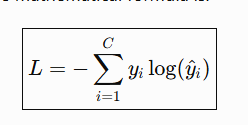

where: C = number of classes
yi = true label (one-hot encoded)
y^i = predicted probability from Softmax

In [7]:
class CrossEntropy:
    def __call__(self, predictions, targets):
        eps = 1e-8
        correct_probs = predictions[
            torch.arange(targets.shape[0]),
            targets
        ]
        loss = -torch.log(correct_probs + eps)
        return loss.mean()

# Training Loop

In [33]:
model = SoftmaxRegression(input_feature=2, num_class=3)

loss_fn = CrossEntropy()
optimizer = SGD(params=[model.W,model.B],lr=0.01)

for epoch in range(5000):

    y_pred = model(X)
    loss = loss_fn(y_pred,y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    predictions = torch.argmax(y_pred, dim=1)
    accuracy = (predictions == y).float().mean()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Accuracy: {accuracy} | Loss: {loss.item():.4f}")

Epoch 0 | Accuracy: 0.36000001430511475 | Loss: 3.6487
Epoch 500 | Accuracy: 0.996666669845581 | Loss: 0.0415
Epoch 1000 | Accuracy: 0.996666669845581 | Loss: 0.0274
Epoch 1500 | Accuracy: 1.0 | Loss: 0.0217
Epoch 2000 | Accuracy: 1.0 | Loss: 0.0185
Epoch 2500 | Accuracy: 1.0 | Loss: 0.0164
Epoch 3000 | Accuracy: 1.0 | Loss: 0.0149
Epoch 3500 | Accuracy: 1.0 | Loss: 0.0137
Epoch 4000 | Accuracy: 1.0 | Loss: 0.0128
Epoch 4500 | Accuracy: 1.0 | Loss: 0.0120
